# Análise Visual da Dedução de Estados dos Nós

Este notebook carrega o resultado do pipeline de análise (`nodes_analysis.csv`) e gera visualizações para entender a eficácia de cada regra de dedução e o status final dos nós.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configurações de estilo para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['figure.dpi'] = 90

# Nome do arquivo de entrada
ARQUIVO_NOS = 'nodes_analysis.csv'

In [2]:
if not os.path.exists(ARQUIVO_NOS):
    print(f"🚨 ERRO: Arquivo '{ARQUIVO_NOS}' não encontrado. Execute o script 'gerar_mapa_e_analise.py' primeiro.")
else:
    df = pd.read_csv(ARQUIVO_NOS)
    print("✅ DataFrame carregado com sucesso!")
    print(f"Total de nós únicos encontrados: {len(df)}")
    display(df.head())
    
    # Preenche valores NaN nas colunas de regras para evitar erros
    colunas_regras = ['R1_POP_Origem', 'R2_POP_Destino', 'R3_Hostname_MatchPerfeito', 'R4_Inferencia_Vizinhanca']
    for col in colunas_regras:
        if col in df.columns:
            df[col] = df[col].fillna('')

✅ DataFrame carregado com sucesso!
Total de nós únicos encontrados: 410


,chave_unica_no,nome,ip,R1_POP_Origem,R2_POP_Destino,R3_Hostname_MatchPerfeito,R4_Inferencia_Vizinhanca,estado_final,status_final
0,|200.139.7.252,NaN,200.139.7.252,AC,NaN,NaN,NaN,AC,DEFINIDO
1,|200.139.4.20,NaN,200.139.4.20,NaN,NaN,NaN,AC,AC,DEFINIDO
2,mxac-bac1.bkb.rnp.br|170.79.214.218,mxac-bac1.bkb.rnp.br,170.79.214.218,NaN,NaN,NaN,AC,AC,DEFINIDO
3,csp2-mxac-3g-allo.bkb.rnp.br|170.79.213.245,csp2-mxac-3g-allo.bkb.rnp.br,170.79.213.245,NaN,NaN,NaN,NaN,NaN,INDEFINIDO
4,cce1-csp2-100g-monet.bkb.rnp.br|170.79.213.60,cce1-csp2-100g-monet.bkb.rnp.br,170.79.213.60,NaN,NaN,NaN,SE,SE,DEFINIDO


## 1. Contagem de Nós por Estado para Cada Regra de Dedução

Os gráficos a seguir mostram quantos nós foram atribuídos a cada estado por cada uma das 4 regras de dedução. Isso nos ajuda a ver o alcance e a distribuição de cada regra.

C:\Users\esdn6\AppData\Local\Temp\ipykernel_17080\1175522239.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=contagem.index, y=contagem.values, palette='viridis')


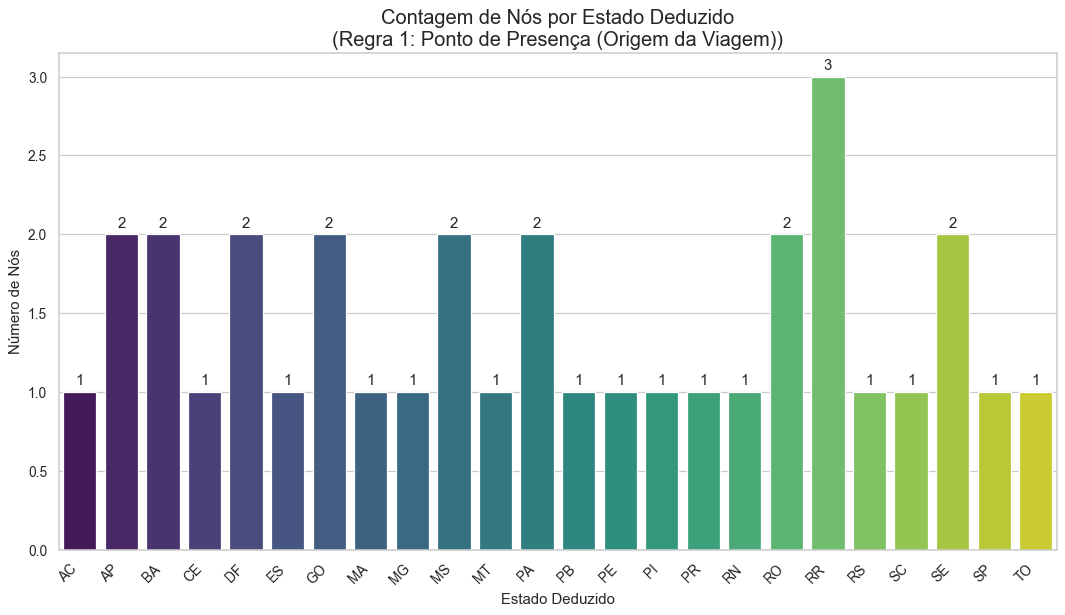

C:\Users\esdn6\AppData\Local\Temp\ipykernel_17080\1175522239.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=contagem.index, y=contagem.values, palette='viridis')


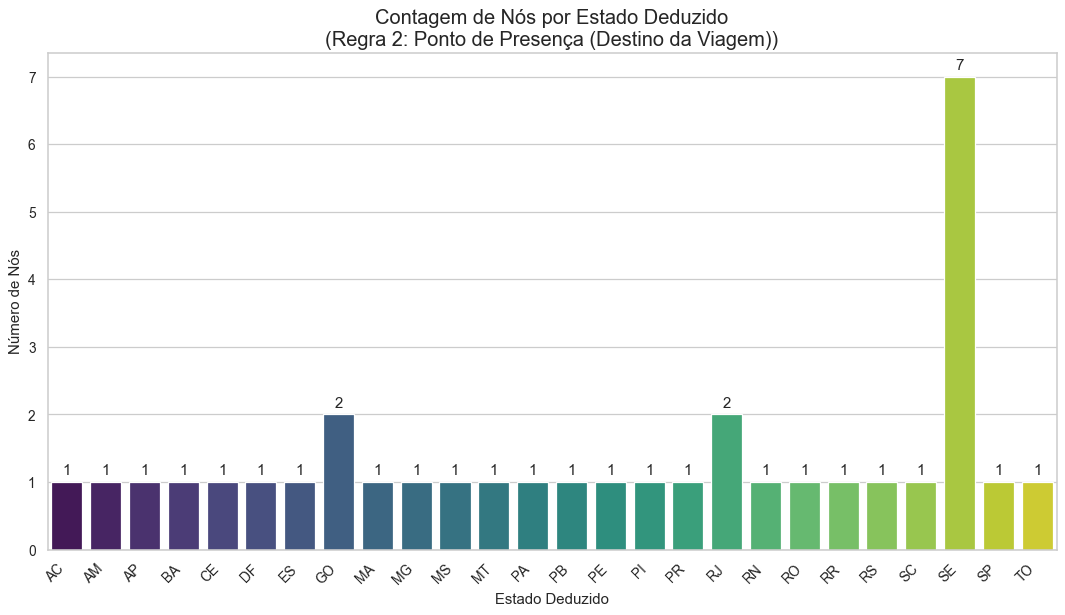

C:\Users\esdn6\AppData\Local\Temp\ipykernel_17080\1175522239.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=contagem.index, y=contagem.values, palette='viridis')


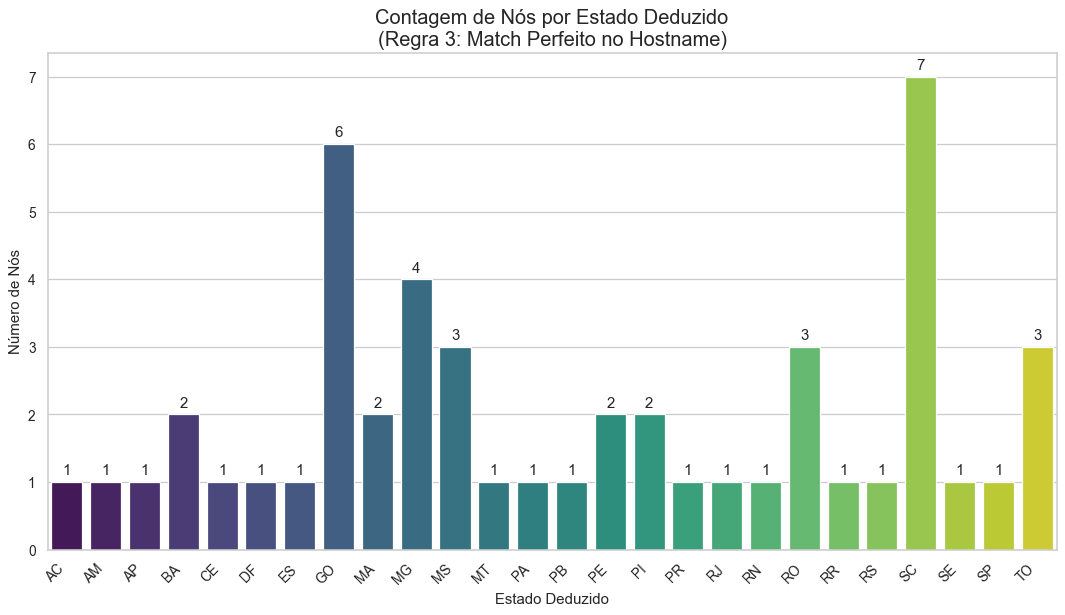

C:\Users\esdn6\AppData\Local\Temp\ipykernel_17080\1175522239.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=contagem.index, y=contagem.values, palette='viridis')


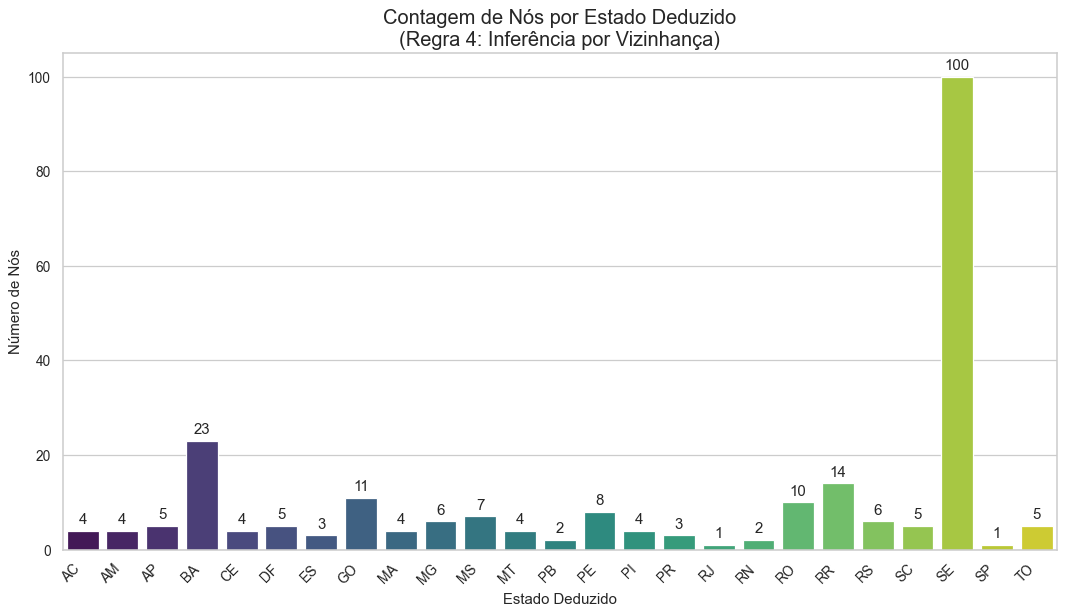

In [3]:
regras_info = {
    'R1_POP_Origem': 'Regra 1: Ponto de Presença (Origem da Viagem)',
    'R2_POP_Destino': 'Regra 2: Ponto de Presença (Destino da Viagem)',
    'R3_Hostname_MatchPerfeito': 'Regra 3: Match Perfeito no Hostname',
    'R4_Inferencia_Vizinhanca': 'Regra 4: Inferência por Vizinhança'
}

for coluna, titulo in regras_info.items():
    # Filtra apenas as deduções válidas para a regra atual
    dados_regra = df[df[coluna] != '']
    
    if dados_regra.empty:
        print(f"\n--- {titulo} ---")
        print("Nenhuma dedução encontrada para esta regra.")
        continue

    # Conta o número de nós por estado
    contagem = dados_regra[coluna].value_counts().sort_index()
    
    plt.figure() # Cria uma nova figura para cada gráfico
    ax = sns.barplot(x=contagem.index, y=contagem.values, palette='viridis')
    
    ax.set_title(f'Contagem de Nós por Estado Deduzido\n({titulo})', fontsize=16)
    ax.set_xlabel('Estado Deduzido', fontsize=12)
    ax.set_ylabel('Número de Nós', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Adiciona os valores no topo das barras
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')
    
    plt.tight_layout()
    plt.show()

## 2. Contagem Final de Nós por Status

Este gráfico resume o resultado final do pipeline, mostrando quantos nós foram classificados como `DEFINIDO` (dedução única e consistente), `CONFLITO` (deduções múltiplas e inconsistentes) ou `INDEFINIDO` (nenhuma regra se aplicou).

C:\Users\esdn6\AppData\Local\Temp\ipykernel_17080\3860179836.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=contagem_status.index, y=contagem_status.values, palette='magma')


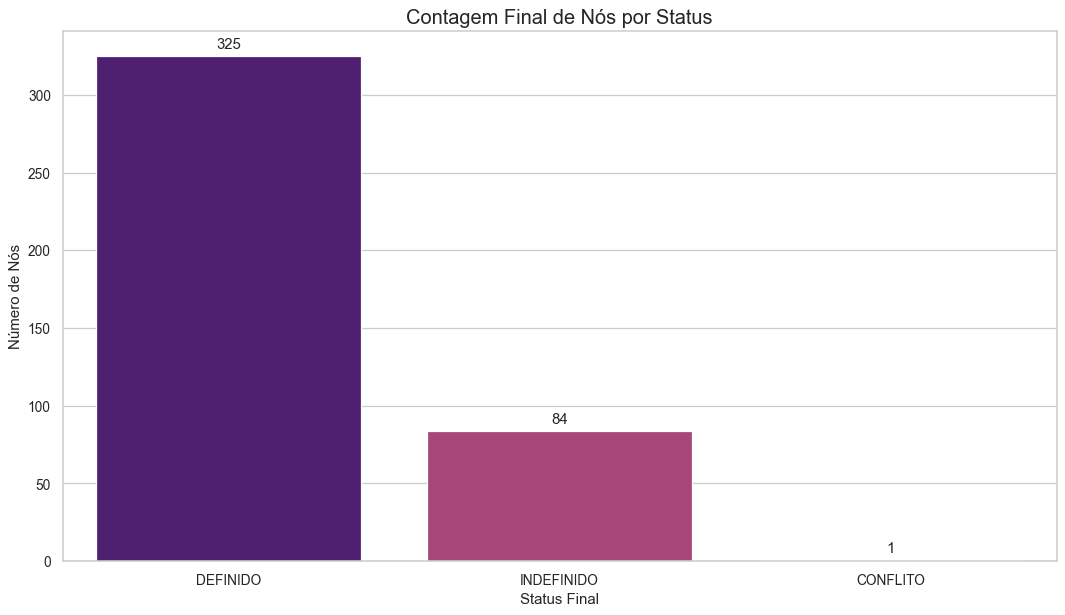

In [4]:
contagem_status = df['status_final'].value_counts()

plt.figure()
ax = sns.barplot(x=contagem_status.index, y=contagem_status.values, palette='magma')

ax.set_title('Contagem Final de Nós por Status', fontsize=16)
ax.set_xlabel('Status Final', fontsize=12)
ax.set_ylabel('Número de Nós', fontsize=12)

# Adiciona os valores no topo das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.show()